In [170]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

In [171]:
# ------------------------------------------------------------------
# --- 0. ФИЗИЧЕСКИЕ КОНСТАНТЫ И ОПРЕДЕЛЕНИЯ МАТЕРИАЛОВ -------------
# ------------------------------------------------------------------

In [172]:
NA = 6.022e23  # Число Авогадро [моль^-1]

In [173]:
class Material:
    """
    Представление физических и макроскопических свойств материала.

    Класс преобразует микроскопические сечения (барн) в макроскопические
    сечения ($cm^{-1}$) на основе плотности и молярной массы.

    Parameters
    ----------
    - name (str):
        Название материала.
    - density (float):
        Плотность материала [г/см³].
    - molar_mass (float):
        Молярная масса [г/моль].
    - sigma_f (float):
        Микроскопическое сечение деления (fission) [барн].
    - sigma_c (float):
        Микроскопическое сечение захвата (capture) [барн].
    - sigma_s (float):
        Микроскопическое сечение рассеяния (scattering) [барн].
    - nu (float):
        Среднее число вторичных нейтронов на один акт деления.

    Notes
    -----
    • *Рабочие гипотезы*
    - Материал считается изотропным и гомогенным.
    - Односкоростная модель: все сечения указаны для фиксированной энергии (~2 МэВ).

    • *Математический фундамент*
    - Концентрация ядер: $n = \frac{\rho \cdot N_A}{M}$
    - Макроскопическое сечение: $\Sigma = n \cdot \sigma \cdot 10^{-24}$
    """
    def __init__(self, name, density, molar_mass, sigma_f, sigma_c, sigma_s, nu):
        self.name = name
        self.rho = density
        
        # 1. Вычисление концентрации ядер (ядер/см^3)
        n = (density * NA) / molar_mass
        
        # 2. Перевод из барн в см^2 (1 barn = 10^-24 cm^2)
        to_cm = 1e-24
        
        # 3. Расчет макроскопических сечений (см^-1)
        self.S_f = n * sigma_f * to_cm
        self.S_c = n * sigma_c * to_cm
        self.S_s = n * sigma_s * to_cm
        self.S_t = self.S_f + self.S_c + self.S_s
        self.nu = nu

<>:32: SyntaxWarning: invalid escape sequence '\c'
<>:32: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Skif\AppData\Local\Temp\ipykernel_25800\4048516605.py:32: SyntaxWarning: invalid escape sequence '\c'
  - Концентрация ядер: $n = \frac{\rho \cdot N_A}{M}$


In [174]:
# Инициализация материалов для симуляции
# U-235: Основное топливо
U235 = Material("U-235", 18.7, 235,
                sigma_f=1.29, sigma_c=0.06, sigma_s=3.87, nu=2.6)

# U-238: Отражатель (Тампер). Деление подавлено для односкоростной модели.
U238 = Material("U-238 (Tamper)", 18.9, 238,
                sigma_f=0, sigma_c=0.015, sigma_s=5, nu=0)

In [175]:
# ------------------------------------------------------------------
# --- 1. ЛОГИКА МОДЕЛИРОВАНИЯ (MONTE CARLO) ------------------------
# ------------------------------------------------------------------

In [176]:
def run_experiment(R_core, thickness_refl, refl_material, N_neutrons, seed):
    """
    Запуск одиночного эксперимента по расчету k_eff методом Монте-Карло.

    Reference
    ---------
    E. Woodcock et al., "Techniques used in the GEM code for Monte Carlo 
    neutronics calculations in multi-region geometries", 1965.

    Parameters
    ----------
    - R_core (float):
        Радиус делящегося ядра [см].
    - thickness_refl (float):
        Толщина отражателя [см].
    - refl_material (Material):
        Объект класса Material, описывающий отражатель.
    - N_neutrons (int):
        Количество моделируемых нейтронов (историй).
    - seed (int):
        Зерно генератора случайных чисел для воспроизводимости.

    Returns
    -------
    - k_eff (float):
        Эффективный коэффициент размножения (fission_neutrons / N_neutrons).

    Notes
    -----
    • *Алгоритм Woodcock tracking (Delta-tracking)*
    1. Определяется мажорантное сечение $\Sigma_{maj} = \max(\Sigma_{total, i})$.
    2. Длина свободного пробега выбирается на основе $\Sigma_{maj}$.
    3. При столкновении "фиктивное" это событие или реальное определяется 
       отношением $\Sigma_{local} / \Sigma_{maj}$.
    
    • *Рабочие гипотезы*
    - Изотропный источник внутри ядра (распределение $r^3$).
    - Упругое изотропное рассеяние.
    - Отсутствие энергетической зависимости сечений (одна группа).
    """
    np.random.seed(seed)
    
    # --------------------------------------------------------------
    # === 1. Инициализация геометрии и сечений =====================
    # --------------------------------------------------------------
    R_total = R_core + thickness_refl
    # Мажорантное сечение для Woodcock tracking
    Sigma_maj = max(U235.S_t, refl_material.S_t) if thickness_refl > 0 else U235.S_t

    fission_neutrons = 0

    # --------------------------------------------------------------
    # === 2. Основной цикл по историям нейтронов ===================
    # --------------------------------------------------------------
    for _ in range(N_neutrons):
        # 2a. Генерация начальных координат (равномерно по объему шара)
        # Shape: (3,)
        r = R_core * (np.random.rand())**(1/3)
        costheta = 2 * np.random.rand() - 1
        phi = 2 * np.pi * np.random.rand()
        sintheta = np.sqrt(1 - costheta**2)
        
        x = r * sintheta * np.cos(phi)
        y = r * sintheta * np.sin(phi)
        z = r * costheta

        # 2b. Генерация изотропного направления движения
        # Shape: (3,)
        costheta_dir = 2 * np.random.rand() - 1
        phi_dir = 2 * np.pi * np.random.rand()
        sintheta_dir = np.sqrt(1 - costheta_dir**2)
        
        u = sintheta_dir * np.cos(phi_dir)
        v = sintheta_dir * np.sin(phi_dir)
        w = costheta_dir

        alive = True
        while alive:
            # ------------------------------------------------------
            # === 3. Перенос частицы (Woodcock tracking) ===========
            # ------------------------------------------------------
            # Выбор длины пробега до следующего столкновения
            d_path = -np.log(np.random.rand()) / Sigma_maj
            
            # Обновление координат
            x += u * d_path
            y += v * d_path
            z += w * d_path
            
            # Расчет текущего радиуса (скаляр)
            r_sq = x*x + y*y + z*z

            # Условие вылета за пределы системы
            if r_sq > R_total**2:
                alive = False
                continue

            # Определение локального материала
            is_core = r_sq <= R_core**2
            mat = U235 if is_core else refl_material

            # ------------------------------------------------------
            # === 4. Розыгрыш типа взаимодействия ==================
            # ------------------------------------------------------
            # Проверка на "реальное" столкновение
            if np.random.rand() < (mat.S_t / Sigma_maj):
                rand_type = np.random.rand() * mat.S_t
                
                # Case A: Деление
                if rand_type < mat.S_f:
                    fission_neutrons += mat.nu
                    alive = False
                # Case B: Радиационный захват
                elif rand_type < (mat.S_f + mat.S_c):
                    alive = False
                # Case C: Рассеяние (смена направления)
                else:
                    costheta_new = 2 * np.random.rand() - 1
                    phi_new = 2 * np.pi * np.random.rand()
                    sintheta_new = np.sqrt(1 - costheta_new**2)
                    # Shape: (3,)
                    u = sintheta_new * np.cos(phi_new)
                    v = sintheta_new * np.sin(phi_new)
                    w = costheta_new

    return fission_neutrons / N_neutrons

<>:31: SyntaxWarning: invalid escape sequence '\S'
<>:31: SyntaxWarning: invalid escape sequence '\S'
C:\Users\Skif\AppData\Local\Temp\ipykernel_25800\1923495215.py:31: SyntaxWarning: invalid escape sequence '\S'
  1. Определяется мажорантное сечение $\Sigma_{maj} = \max(\Sigma_{total, i})$.


In [177]:
def simulate_range(radii, thickness_refl, refl_material, N_seeds, N_neutrons):
    """
    Проведение серии экспериментов для диапазона радиусов ядра.

    Parameters
    ----------
    - radii (np.ndarray, shape=(N_radii,)):
        Массив радиусов активной зоны для исследования.
    - thickness_refl (float):
        Толщина отражателя [см].
    - refl_material (Material):
        Материал отражателя.
    - N_seeds (int):
        Количество статистических реализаций (запусков) для каждой точки.
    - N_neutrons (int):
        Количество нейтронов в одном запуске.

    Returns
    -------
    - means (np.ndarray, shape=(N_radii,)):
        Средние значения k_eff для каждого радиуса.
    - errors (np.ndarray, shape=(N_radii,)):
        Доверительный интервал (2*SEM).
    """
    means, errors = [], []
    desc = f"Refl {thickness_refl}cm" if thickness_refl > 0 else "Bare"
    
    for R in tqdm(radii, desc=desc):
        k_vals = []
        # Генерация детерминированного базового семени
        base_seed = int(R*10000) + int(thickness_refl*100) + 999
        
        # Цикл по статистическим реализациям (Seeds)
        for i in range(N_seeds):
            k = run_experiment(R, thickness_refl, refl_material, N_neutrons, seed=base_seed+i)
            k_vals.append(k)
            
        # Расчет среднего и стандартной ошибки (SEM)
        mean_k = np.mean(k_vals)
        sem = np.std(k_vals, ddof=1) / np.sqrt(N_seeds)
        
        means.append(mean_k)
        errors.append(2 * sem)
        
    return np.array(means), np.array(errors)

In [178]:
# ------------------------------------------------------------------
# --- 2. УТИЛИТЫ АНАЛИЗА ДАННЫХ ------------------------------------
# ------------------------------------------------------------------

In [179]:
def find_critical(x, y):
    """
    Линейная интерполяция для поиска критической точки k_eff = 1.0.

    Parameters
    ----------
    - x (np.ndarray):
        Массив аргументов (радиусов).
    - y (np.ndarray):
        Массив значений (k_eff).

    Returns
    -------
    - critical_radius (float or None):
        Радиус, при котором k_eff = 1.0.
    """
    for i in range(len(y)-1):
        if (y[i]-1)*(y[i+1]-1) <= 0:
            # Линейная интерполяция: y = kx + b
            slope = (y[i+1]-y[i])/(x[i+1]-x[i])
            return x[i] + (1.0 - y[i])/slope
    return None

In [180]:
# ------------------------------------------------------------------
# --- 3. ВЫПОЛНЕНИЕ РАСЧЕТОВ ---------------------------------------
# ------------------------------------------------------------------

In [181]:
N_SEEDS = 10
N_PARTICLES = 1000

# Определение сеток радиусов
radii_bare = np.linspace(7.0, 10.5, 9)
radii_refl = np.linspace(4.0, 7.0, 9)

# 1. Расчет для голой сферы
print("1. Расчет голой сферы...")
k_bare, err_bare = simulate_range(radii_bare, 0.0, U235, N_SEEDS, N_PARTICLES)

# 2. Расчет для сферы с тампером (отражателем) из U-238
print(f"2. Расчет с тампером U-238 (18.01 см)...")
k_refl, err_refl = simulate_range(radii_refl, 18.0086, U238, N_SEEDS, N_PARTICLES)

# Поиск критических параметров
Rc_bare_val = find_critical(radii_bare, k_bare)
Rc_refl_val = find_critical(radii_refl, k_refl)

1. Расчет голой сферы...


Bare: 100%|██████████| 9/9 [00:03<00:00,  2.84it/s]


2. Расчет с тампером U-238 (18.01 см)...


Refl 18.0086cm: 100%|██████████| 9/9 [00:12<00:00,  1.41s/it]


In [182]:
# ------------------------------------------------------------------
# --- 4. ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ----------------------------------
# ------------------------------------------------------------------

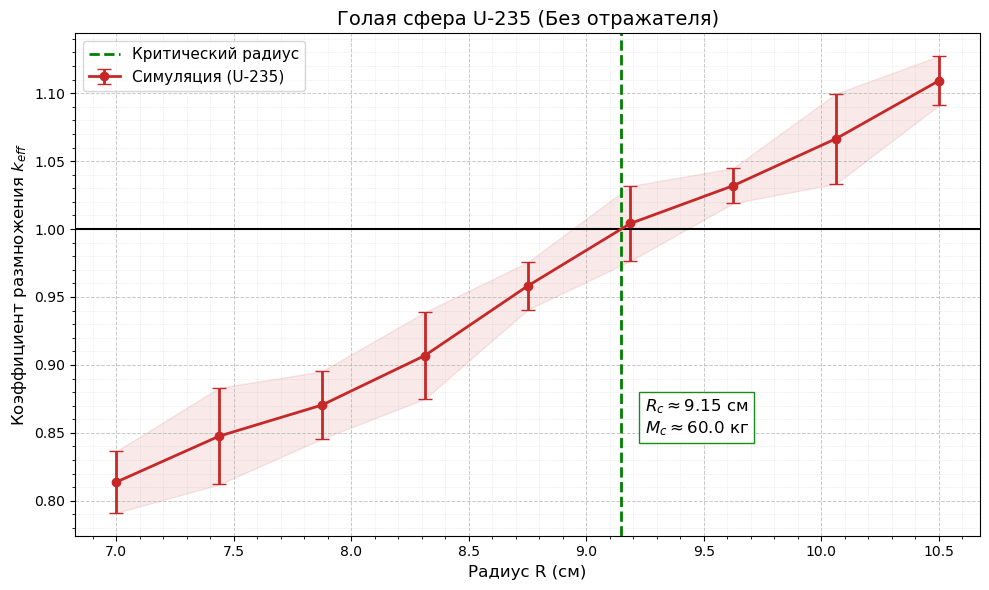

In [183]:
# --- График 1: Анализ критичности голой сферы ---
plt.figure(figsize=(10, 6))
plt.errorbar(radii_bare, k_bare, yerr=err_bare, fmt='o-', color='#C62828',
             capsize=5, label='Симуляция (U-235)', markersize=6, linewidth=2)
plt.fill_between(radii_bare, k_bare-err_bare, k_bare+err_bare, color='#C62828', alpha=0.1)
plt.axhline(1.0, color='black', linestyle='-', linewidth=1.5)

plt.title("Голая сфера U-235 (Без отражателя)", fontsize=14)
plt.xlabel("Радиус R (см)", fontsize=12)
plt.ylabel("Коэффициент размножения $k_{eff}$", fontsize=12)

plt.minorticks_on()
plt.grid(which='major', linestyle='--', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

if Rc_bare_val:
    M_crit = 4/3 * np.pi * Rc_bare_val**3 * U235.rho / 1000
    plt.axvline(Rc_bare_val, color='green', linestyle='--', linewidth=2, label='Критический радиус')
    plt.text(Rc_bare_val + 0.1, 0.85,
             f"$R_c \\approx {Rc_bare_val:.2f}$ см\n$M_c \\approx {M_crit:.1f}$ кг",
             fontsize=12, bbox=dict(facecolor='white', edgecolor='green', alpha=0.9))

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("1.pdf")
plt.show()

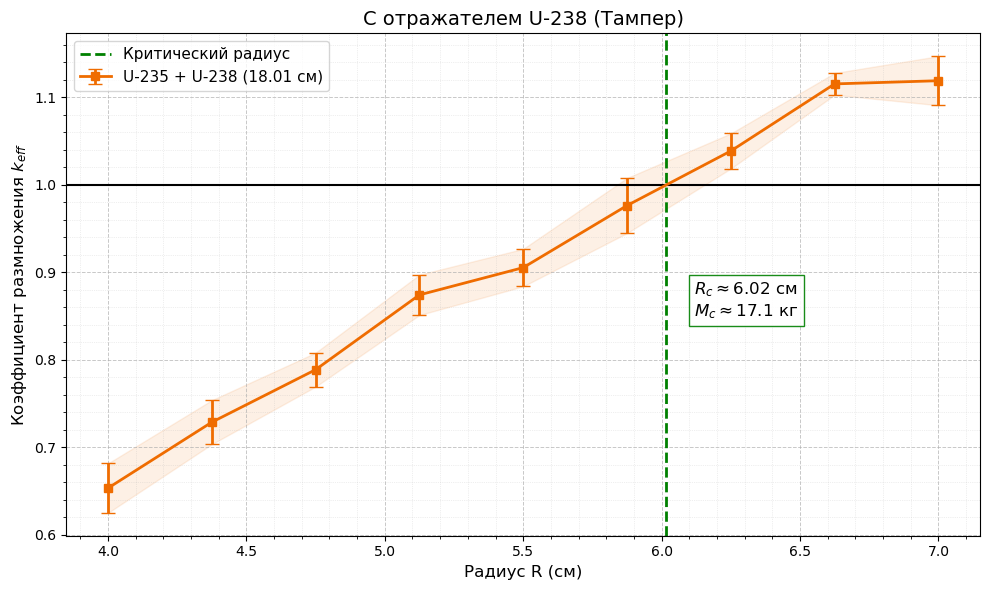

Rc (bare): 9.148 cm
Rc (refl): 6.017 cm


In [184]:
# --- График 2: Анализ критичности сферы с отражателем ---
plt.figure(figsize=(10, 6))
plt.errorbar(radii_refl, k_refl, yerr=err_refl, fmt='s-', color='#EF6C00',
             capsize=5, label='U-235 + U-238 (18.01 см)', markersize=6, linewidth=2)
plt.fill_between(radii_refl, k_refl-err_refl, k_refl+err_refl, color='#EF6C00', alpha=0.1)
plt.axhline(1.0, color='black', linestyle='-', linewidth=1.5)

plt.title("С отражателем U-238 (Тампер)", fontsize=14)
plt.xlabel("Радиус R (см)", fontsize=12)
plt.ylabel("Коэффициент размножения $k_{eff}$", fontsize=12)

plt.minorticks_on()
plt.grid(which='major', linestyle='--', linewidth=0.7, alpha=0.7)
plt.grid(which='minor', linestyle=':', linewidth=0.5, alpha=0.4)

if Rc_refl_val:
    M_crit = 4/3 * np.pi * Rc_refl_val**3 * U235.rho / 1000
    plt.axvline(Rc_refl_val, color='green', linestyle='--', linewidth=2, label='Критический радиус')
    plt.text(Rc_refl_val + 0.1, 0.85,
             f"$R_c \\approx {Rc_refl_val:.2f}$ см\n$M_c \\approx {M_crit:.1f}$ кг",
             fontsize=12, bbox=dict(facecolor='white', edgecolor='green', alpha=0.9))

plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("2.pdf")
plt.show()

# Финальный вывод в консоль
print(f"Rc (bare): {Rc_bare_val:.3f} cm")
print(f"Rc (refl): {Rc_refl_val:.3f} cm")